# Exercise

Let's apply these concepts ourselves. We can build a simple foreground on top of ecoinvent:

In [1]:
import bw2data as bd
import bw2io as bi

In [2]:
bi.restore_project_directory(
    "<path to file>",
    project_name="Temporal exercise",
    overwrite_existing=True,
    switch=True,
)

Restoring project backup archive - this could take a few minutes...
Restored project: Temporal exercise


'Temporal exercise'

In [2]:
bd.projects.set_current("Temporal exercise")

In [3]:
bd.databases

Databases dictionary with 3 object(s):
	Adapted car
	ecoinvent-3.10.1-biosphere
	ecoinvent-3.10.1-cutoff

**Note**: Change needed here, otherwise we don't get interesting results

In [4]:
bd.databases['ecoinvent-3.10.1-biosphere']['static'] = False
bd.databases['ecoinvent-3.10.1-cutoff']['static'] = False
bd.databases.flush()

In [5]:
ei = bd.Database("ecoinvent-3.10.1-cutoff")
len(ei)

23523

You can print all of them and pick the one you like the best.

In [6]:
[ic for ic in bd.methods if "gtp100" in str(ic).lower() and "ipcc 2021" in str(ic).lower()]

[('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: biogenic no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: biogenic, including SLCFs no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: fossil no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: fossil, including SLCFs no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: including SLCFs no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',
  'IPCC 2021 no LT',
  'climate change: land use no LT',
  'global temperature change potential (GTP100) no LT'),
 ('ecoinvent-3.10.1',

In [7]:
import bw_temporalis as bwt
import bw2calc as bc
from linear_decrease import LinearDecreaseOverTime

## The task

- Create a new database
- Pick a car or truck driving process in ecoinvent
- Copy that car or truck process over to a new database
- Pick 1-3 inputs for the car or truck (motive energy, vehicle construction, etc.) and copy those over to the new database
- Relink the copied car or truck to the copied inputs by changing and saving the relevant edges
- Add temporal dynamics to the modified inputs. If you are feeling ambitious, you can also use `LinearDecreaseOverTime`, `FixedTD` or `FixedTimeOfYearTD`.
- Pick an global warming LCIA method
- Perform a temporal LCIA calculation and graph the timeline

### Some helpful methods

* ei.search("something")
* bd.get_node(name="foo", location="bar")  # The attributes can be anything you want
* my_node.production(), my_node.technosphere(), my_node.biosphere(), my_node.consumers()

In the `TemporalisLCA` class initiator, you can change:

* starting_datetime: datetime | str = "now",
* cutoff: float | None = 5e-4,
* biosphere_cutoff: float | None = 1e-6,
* max_calc: int | None = 2e3,

Here is a simple example where you can modify only the direct process without needing to also copy some inputs. Note that you would need to create another process, a functional unit, which used a certain number of vehicle kilometers over some time period.

## Exercise solution

- Create a new database

In [8]:
if "Adapted car" in bd.databases:
    del bd.databases["Adapted car"]

In [9]:
db = bd.Database("Adapted car")
db.register()

- Pick a car or truck driving process in ecoinvent

In [10]:
ei.search("transport, passenger car, small size, diesel, EURO 5 RER")

['transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None),
 'transport, passenger car, medium size, diesel, EURO 5' (kilometer, RER, None),
 'transport, passenger car, small size, diesel, EURO 4' (kilometer, RER, None),
 'transport, passenger car, small size, diesel, EURO 3' (kilometer, RER, None),
 'transport, passenger car, large size, diesel, EURO 5' (kilometer, RER, None),
 'transport, passenger car, medium size, diesel, EURO 3' (kilometer, RER, None),
 'transport, passenger car, medium size, diesel, EURO 4' (kilometer, RER, None),
 'transport, passenger car, large size, diesel, EURO 4' (kilometer, RER, None),
 'transport, passenger car, large size, diesel, EURO 3' (kilometer, RER, None),
 'transport, passenger car' (kilometer, RER, None),
 'market for transport, passenger car' (kilometer, RER, None)]

In [11]:
vroom_vroom = bd.get_node(location="RER", name='transport, passenger car, small size, diesel, EURO 5')
for edge in vroom_vroom.edges():
    print(edge)

Exchange: 1.0 kilometer 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
Exchange: -5.77254e-06 kilogram 'market for brake wear emissions, passenger car' (kilogram, GLO, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
Exchange: 0.04344796 kilogram 'market group for diesel, low-sulfur' (kilogram, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
Exchange: 6.45161290322581e-06 unit 'maintenance, passenger car' (unit, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
Exchange: 0.008 kilogram 'market for passenger car, diesel' (kilogram, GLO, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
Exchange: 0.0006965964 meter-year 'market for road' (meter-year, GLO, None) to 'transport, passenger car, small size, diesel, EURO 5' (

- Copy that car or truck process over to a new database

In [12]:
new_car = vroom_vroom.copy(database=db.name)

- Pick 1-3 inputs for the car or truck (motive energy, vehicle construction, etc.) and copy those over to the new database
- Relink the copied car or truck to the copied inputs by changing and saving the relevant edges

In [13]:
TO_MODIFY = [
    'market for passenger car, diesel',
    'maintenance, passenger car',
    'market group for diesel, low-sulfur',
]

In [14]:
logger = bd.logs.stdout_feedback_logger

In [15]:
for exc in new_car.production():
    print(exc.input["database"], exc.output["database"], exc)

Adapted car Adapted car Exchange: 1.0 kilometer 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)


In [16]:
for edge in new_car.technosphere():
    if edge.input["name"] in TO_MODIFY:
        logger.info(f"Modifying edge {edge}; copying input node {edge.input} to new database")
        new_input = edge.input.copy(database=db.name)
        edge.input = new_input
        edge.save()
        logger.info(f"Created new node {new_input} with id {new_input.id}")

15:02:31+0000 [info     ] Modifying edge Exchange: 0.04344796 kilogram 'market group for diesel, low-sulfur' (kilogram, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None); copying input node 'market group for diesel, low-sulfur' (kilogram, RER, None) to new database
15:02:31+0000 [info     ] Created new node 'market group for diesel, low-sulfur' (kilogram, RER, None) with id 270568476596629504
15:02:31+0000 [info     ] Modifying edge Exchange: 6.45161290322581e-06 unit 'maintenance, passenger car' (unit, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None); copying input node 'maintenance, passenger car' (unit, RER, None) to new database
15:02:31+0000 [info     ] Created new node 'maintenance, passenger car' (unit, RER, None) with id 270568476659544064
15:02:31+0000 [info     ] Modifying edge Exchange: 0.008 kilogram 'market for passenger car, diesel' (kilogram, GLO, None) to 'transport, passenger car, smal

In [17]:
assert len(db) == 4
assert sum(1 for exc in new_car.technosphere() if exc.input["database"] == db.name) == 3

- Add temporal dynamics to the modified inputs. If you are feeling ambitious, you can also use `LinearDecreaseOverTime`, `FixedTD` or `FixedTimeOfYearTD`

In [18]:
for edge in new_car.technosphere():
    if edge.input["name"] == 'market for passenger car, diesel':
        edge['temporal_distribution'] = bwt.easy_timedelta_distribution(
            start=-24,
            end=-12,
            resolution="M",
            steps=12,
        )
        edge.save()
        logger.info(f"Adding temporal dynamics to edge {edge}")
    elif edge.input["name"] == 'maintenance, passenger car':
        edge['temporal_distribution'] = bwt.easy_timedelta_distribution(
            start=2,
            end=4,
            resolution="Y",
            steps=2,
        )
        edge.save()
        logger.info(f"Adding temporal dynamics to edge {edge}")
    elif edge.input["name"] == 'market group for diesel, low-sulfur':
        edge['temporal_distribution'] = bwt.easy_timedelta_distribution(
            start=-6,
            end=-1,
            resolution="M",
            steps=6,
        )
        edge.save()
        logger.info(f"Adding temporal dynamics to edge {edge}")

15:02:34+0000 [info     ] Adding temporal dynamics to edge Exchange: 0.04344796 kilogram 'market group for diesel, low-sulfur' (kilogram, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
15:02:34+0000 [info     ] Adding temporal dynamics to edge Exchange: 6.45161290322581e-06 unit 'maintenance, passenger car' (unit, RER, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)
15:02:34+0000 [info     ] Adding temporal dynamics to edge Exchange: 0.008 kilogram 'market for passenger car, diesel' (kilogram, GLO, None) to 'transport, passenger car, small size, diesel, EURO 5' (kilometer, RER, None)


- Pick an global warming LCIA method

In [19]:
GTP = (
    'ecoinvent-3.10.1',
    'IPCC 2021',
    'climate change',
    'global temperature change potential (GTP100)'
)

- Perform a temporal LCIA calculation and graph the timeline

In [20]:
import bw2calc as bc

In [21]:
demand, data_objs, _ = bd.prepare_lca_inputs({new_car: 1}, method=GTP, remapping=False)

In [22]:
lca = bc.LCA(demand, data_objs=data_objs)
lca.lci()
lca.lcia()

In [23]:
from bw_temporalis.lcia import characterize_methane, characterize_co2

In [24]:
tlca = bwt.TemporalisLCA(lca)
tl = tlca.build_timeline()
tl.build_dataframe()

Starting graph traversal
Calculation count: 707


,date,amount,flow,activity
0,2024-01-17 03:24:22,1.905678e-07,202903470401253401,202903739021258752
1,2024-01-17 03:24:22,2.151482e-12,202903470455779342,202903838862471169
2,2024-01-17 03:24:22,-4.048637e-08,202903470434807811,202903757895626752
3,2024-01-17 03:24:22,-1.533404e-05,202903470401253398,202903757895626752
4,2024-01-17 03:24:22,9.867019e-07,202903470401253401,202903779487903744
...,...,...,...,...
3066,2030-01-16 14:19:34,-1.144353e-04,202903470317367374,202903827424604160
3067,2030-01-16 14:19:34,1.042566e-11,202903470455779342,202903768482050049
3068,2030-01-16 14:19:34,8.883306e-05,202903470401253401,202903764233220096
3069,2030-01-16 14:19:34,3.506778e-05,202903470401253401,202903772240146432


In [25]:
co2 = {
    flow.id 
    for flow in bd.Database("ecoinvent-3.10.1-biosphere") 
    if flow["name"] == "Carbon dioxide, fossil"
}

In [26]:
characterized_df_co2 = tl.characterize_dataframe(
    characterization_function=characterize_co2, 
    flow=co2,
)

<Axes: xlabel='date', ylabel='amount'>

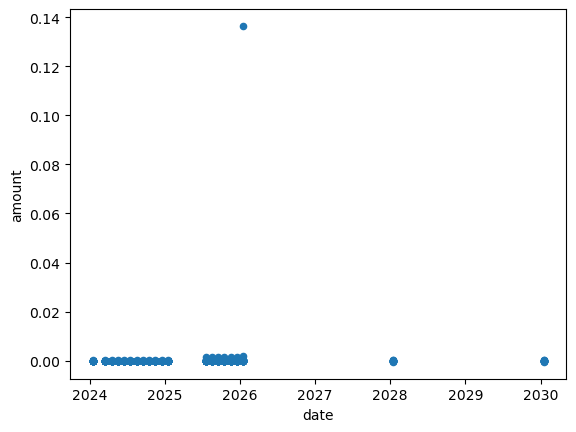

In [27]:
tl.df.plot(x="date", y="amount", kind="scatter")

<Axes: xlabel='date', ylabel='amount_sum'>

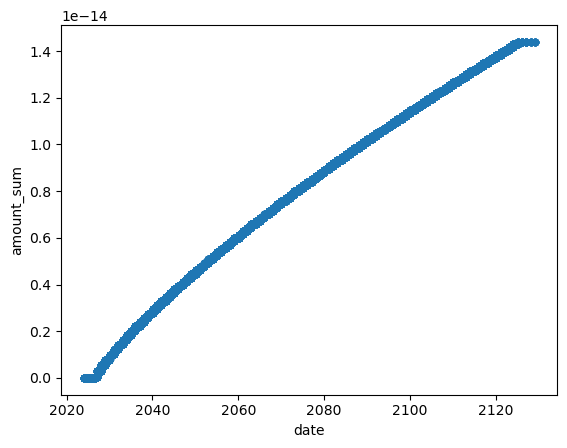

In [28]:
characterized_df_co2.plot(x="date", y="amount_sum", kind="scatter")